# Superstore Sales Performance Analysis

## Introduction

This project analyzes a Superstore sales dataset to understand sales patterns and identify useful business insights.

The analysis focuses on product categories, sub-categories, regions, products, and sales trends over time.

## Objectives

- Explore and understand the dataset.
- Clean the data where necessary.
- Analyze sales across different categories and regions.
- Identify top-performing products.
- Study sales trends over time.
- Use statistical analysis and visualization to identify patterns.

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [41]:
import zipfile
import os

zip_path = "/content/archive.zip"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall("/content/sales_data")

print("Dataset extracted successfully!")
print(os.listdir("/content/sales_data"))

Dataset extracted successfully!
['train.csv']


In [42]:
import os

files = os.listdir("/content/sales_data")
print(files)

['train.csv']


In [43]:
import os
import pandas as pd

# Find CSV files inside the extracted folder
csv_files = []

for root, dirs, files in os.walk("/content/sales_data"):
    for file in files:
        if file.lower().endswith(".csv"):
            csv_files.append(os.path.join(root, file))

print("CSV files found:")
for file in csv_files:
    print(file)

# Load the first CSV file
df = pd.read_csv(csv_files[0])

print("\nDataset loaded successfully!")
print("Rows and columns:", df.shape)

CSV files found:
/content/sales_data/train.csv

Dataset loaded successfully!
Rows and columns: (9800, 18)


In [44]:
print("First 5 rows:")
display(df.head())

print("\nDataset information:")
df.info()

print("\nMissing values:")
print(df.isnull().sum())

First 5 rows:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null  

In [45]:
# Check duplicate rows
print("Duplicate rows:", df.duplicated().sum())

# Remove duplicate rows
df = df.drop_duplicates()

print("Dataset shape after removing duplicates:", df.shape)

Duplicate rows: 0
Dataset shape after removing duplicates: (9800, 18)


In [46]:
df.describe()

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [47]:
print("Column names:")
for column in df.columns:
    print("-", column)

Column names:
- Row ID
- Order ID
- Order Date
- Ship Date
- Ship Mode
- Customer ID
- Customer Name
- Segment
- Country
- City
- State
- Postal Code
- Region
- Product ID
- Category
- Sub-Category
- Product Name
- Sales


In [48]:
print("\nData types:")
print(df.dtypes)


Data types:
Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code      float64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
dtype: object


## Research Questions

1. Which product categories generate the highest sales?
2. Which product categories generate the highest profit?
3. Which regions have the highest sales and profit?
4. How do sales and profit change over time?
5. Is there a relationship between sales and profit?

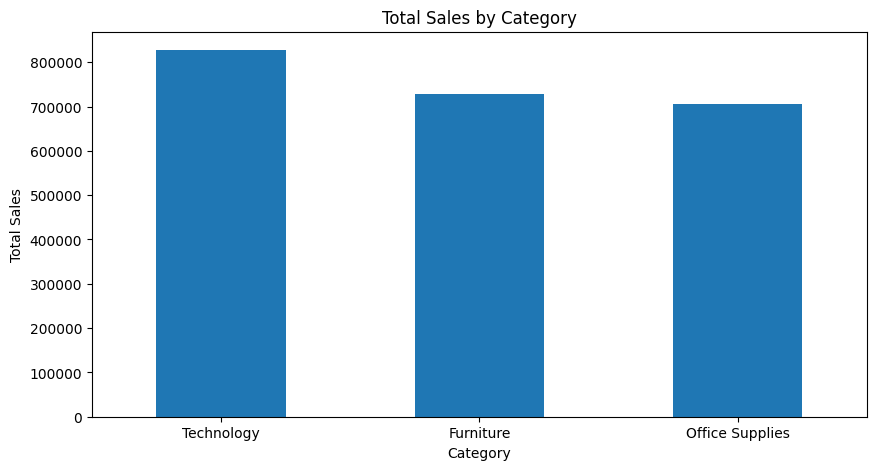

In [49]:
plt.figure(figsize=(10, 5))

category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

category_sales.plot(kind="bar")

plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.show()

In [50]:
print(df.columns.tolist())

['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales']


In [51]:
for i, column in enumerate(df.columns, 1):
    print(i, ":", column)

1 : Row ID
2 : Order ID
3 : Order Date
4 : Ship Date
5 : Ship Mode
6 : Customer ID
7 : Customer Name
8 : Segment
9 : Country
10 : City
11 : State
12 : Postal Code
13 : Region
14 : Product ID
15 : Category
16 : Sub-Category
17 : Product Name
18 : Sales


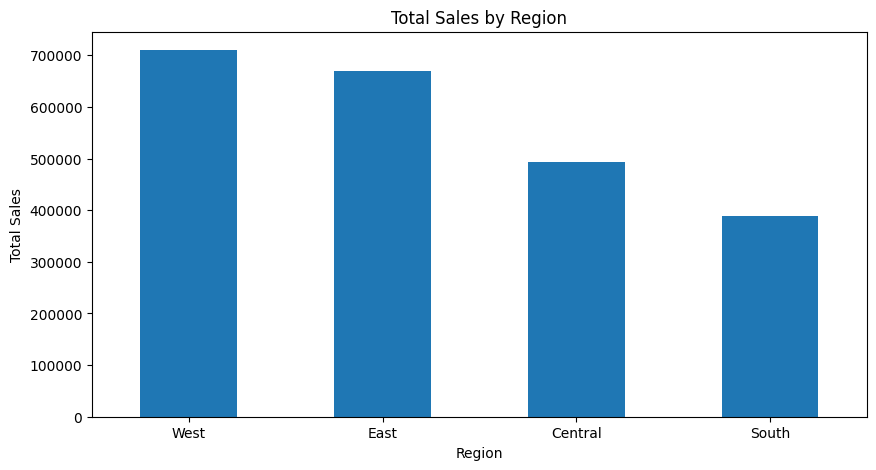

In [52]:
region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
region_sales.plot(kind="bar")

plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.show()

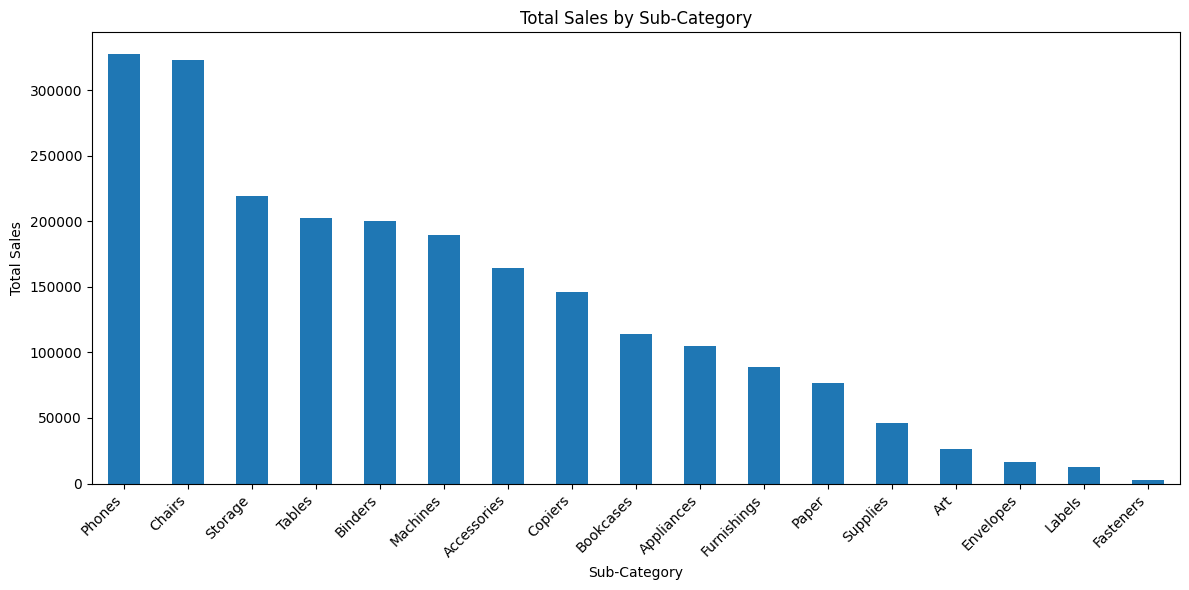

In [53]:
subcategory_sales = df.groupby("Sub-Category")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
subcategory_sales.plot(kind="bar")

plt.title("Total Sales by Sub-Category")
plt.xlabel("Sub-Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

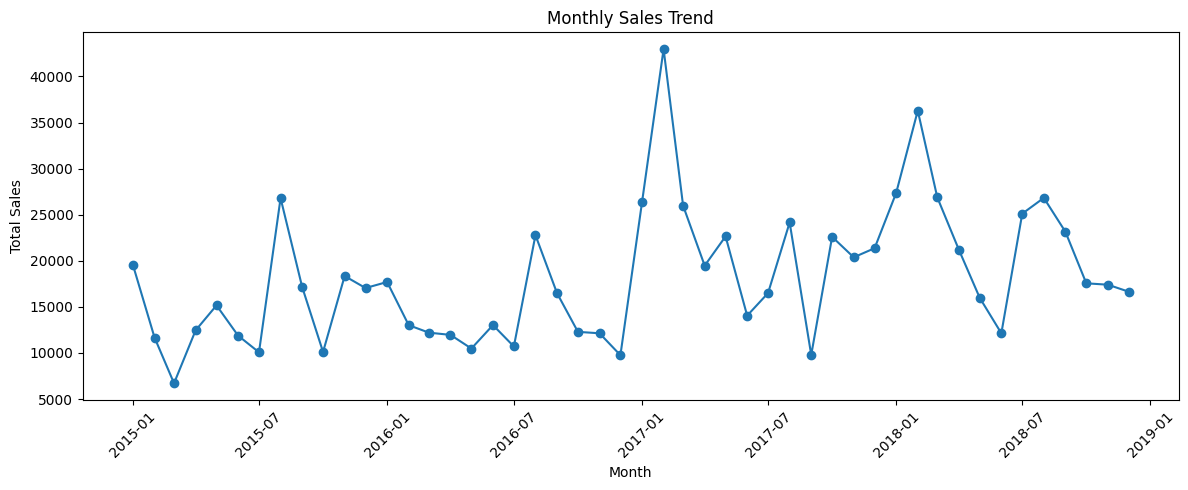

In [54]:
# Convert Order Date to date format
df["Order Date"] = pd.to_datetime(df["Order Date"], errors="coerce")

# Calculate monthly sales
monthly_sales = df.groupby(df["Order Date"].dt.to_period("M"))["Sales"].sum()

# Convert period to timestamp for plotting
monthly_sales.index = monthly_sales.index.to_timestamp()

# Create the graph
plt.figure(figsize=(12, 5))
plt.plot(monthly_sales.index, monthly_sales.values, marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

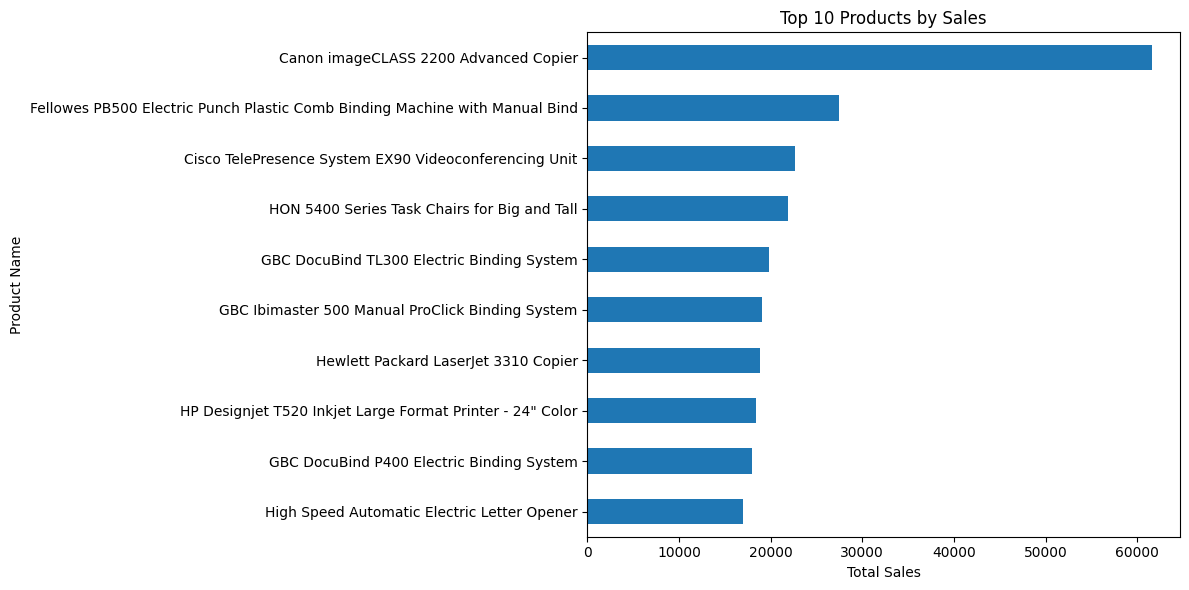

In [55]:
top_products = (
    df.groupby("Product Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))
top_products.sort_values().plot(kind="barh")

plt.title("Top 10 Products by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Product Name")
plt.tight_layout()
plt.show()

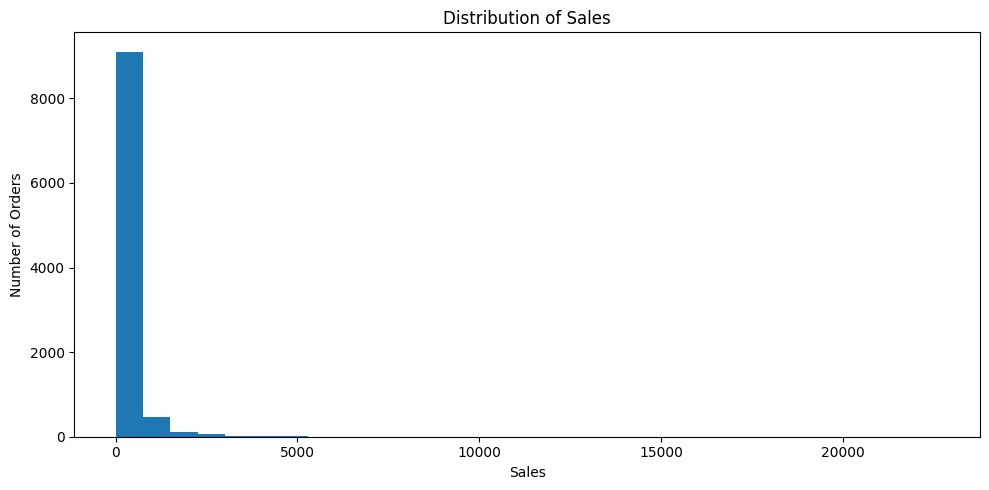

In [56]:
plt.figure(figsize=(10, 5))

plt.hist(df["Sales"], bins=30)

plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.show()

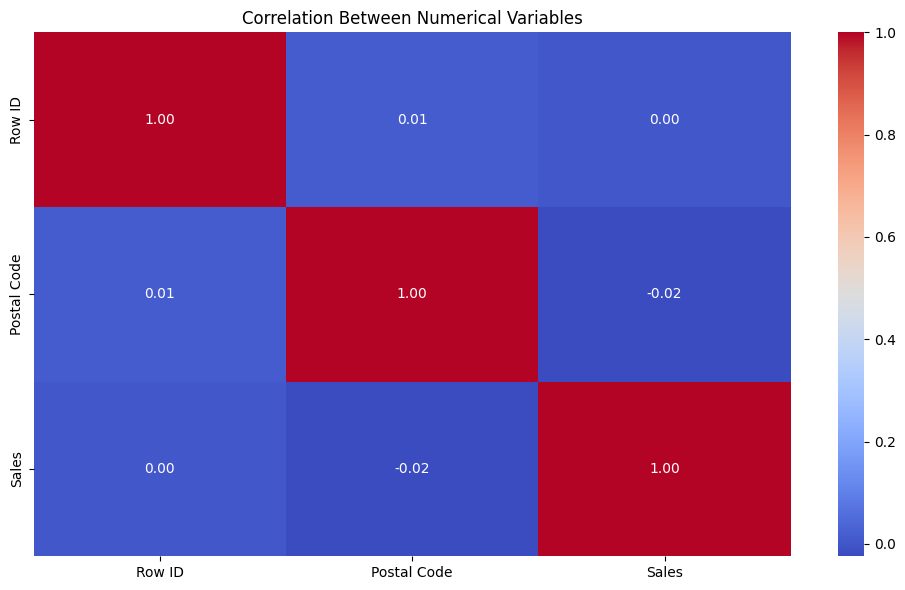

In [57]:
# Select numerical columns
numeric_df = df.select_dtypes(include="number")

# Calculate correlation
correlation = numeric_df.corr()

# Create heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Between Numerical Variables")
plt.tight_layout()
plt.show()

## Findings and Insights

1. The analysis shows differences in sales performance across product categories and regions.

2. The sub-category analysis helps identify the products that contribute most to overall sales.

3. The monthly sales analysis shows changes in sales over time and helps identify periods of higher and lower sales.

4. The top-product analysis identifies the individual products with the highest contribution to sales.

5. The sales distribution shows how order values are spread across the dataset.

6. The correlation analysis helps identify relationships among the numerical variables.

## Conclusion

This project analyzed the Superstore sales dataset using Python, Pandas, Matplotlib, and Seaborn. The analysis included data exploration, data cleaning, statistical analysis, and multiple visualizations. The results provide useful insights into sales patterns, regional performance, product performance, and relationships between numerical variables.